In [44]:
import numpy as np

## module neville
''' p = neville(xData,yData,x).
    Evaluates the polynomial interpolant p(x) that passes
    trough the specified data points by Neville's method.
'''
def neville(xData,yData,x):
    m = len(xData)   # number of data points
    y = yData.copy()
    for k in range(1,m):
        y[0:m-k] = ((x - xData[k:m])*y[0:m-k] +      \
                    (xData[0:m-k] - x)*y[1:m-k+1])/  \
                    (xData[0:m-k] - xData[k:m])
    return y[0]

xData = np.array([0,0.5,1,1.5,2])
yData = np.array([-1,1.75,4.00,5.75,7.00])

x = np.pi/4
print(neville(xData,yData,x))


3.095538705316605


In [45]:
import sympy as sp

def lagrange(x_points, y_points):
    x = sp.symbols('x')
    n = len(x_points)
    P = 0

    for i in range(n):
        L = 1
        for j in range(n):
            if i != j:
                L *= (x - x_points[j]) / (x_points[i] - x_points[j])
        P += y_points[i] * L

    return sp.expand(P)

x_points = [0,3,6]
y_points = [1.225,0.905,0.652]
P = lagrange(x_points,y_points)
print(lagrange(x_points, y_points))
print(f'Air Density at 5 km = {P.subs('x',5):.3f} kg/m^3')


0.00372222222222224*x**2 - 0.117833333333333*x + 1.225
Air Density at 5 km = 0.729 kg/m^3


In [46]:
## module newtonPoly
import numpy as np
''' p = evalPoly(a,xData,x).
    Evaluates Newton's polynomial p at x. The coefficient
    vector 'a' can be computed by the function 'coeffts'.

    a = coeffts(xData,yData).
    Computes the coefficients of Newton's polynomial.
'''
def evalPoly(a,xData,x):
    n = len(xData) - 1  # Degree of polynomial
    p = a[n]
    for k in range(1,n+1):
        p = a[n-k] + (x -xData[n-k])*p
    return p

def coeffts(xData,yData):
    m = len(xData)  # Number of data points
    a = yData.copy()
    for k in range(1,m):
        a[k:m] = (a[k:m] - a[k-1])/(xData[k:m] - xData[k-1])
    return a

xData = np.array([-3,-1,1,2,3])
yData = np.array([0,-4,0,5,12])

x = 0.5
a = coeffts(xData,yData)
print(a)
print(evalPoly(a,xData,x))

[ 0 -2  1  0  0]
-1.75


In [47]:
## module LUdecomp3
''' c,d,e = LUdecomp3(c,d,e).
    LU decomposition of tridiagonal matrix [a], where {c}, {d}
    and {e} are the diagonals of [a]. On output
    {c},{d} and {e} are the diagonals of the decomposed matrix.

    x = LUsolve3(c,d,e,b).
    Solution of [a]{x} {b}, where {c}, {d} and {e} are the
    vectors returned from LUdecomp3.
'''

def LUdecomp3(c,d,e):
    n = len(d)
    for k in range(1,n):
        lam = c[k-1]/d[k-1]
        d[k] = d[k] - lam*e[k-1]
        c[k-1] = lam
    return c,d,e

def LUsolve3(c,d,e,b):
    n = len(d)
    for k in range(1,n):
        b[k] = b[k] - c[k-1]*b[k-1]
    b[n-1] = b[n-1]/d[n-1]
    for k in range(n-2,-1,-1):
        b[k] = (b[k] - e[k]*b[k+1])/d[k]
    return b

## module cubicSpline
''' k = curvatures(xData,yData).
    Returns the curvatures of cubic spline at its knots.

    y = evalSpline(xData,yData,k,x).
    Evaluates cubic spline at x. The curvatures k can be
    computed with the function 'curvatures'.
'''
import numpy as np

def curvatures(xData,yData):
    n = len(xData) - 1
    c = np.zeros(n)
    d = np.ones(n+1)
    e = np.zeros(n)
    k = np.zeros(n+1)
    c[0:n-1] = xData[0:n-1] - xData[1:n]
    d[1:n] = 2.0*(xData[0:n-1] - xData[2:n+1])
    e[1:n] = xData[1:n] - xData[2:n+1]
    k[1:n] =6.0*(yData[0:n-1] - yData[1:n]) \
                 /(xData[0:n-1] - xData[1:n]) \
             -6.0*(yData[1:n] - yData[2:n+1])   \
                 /(xData[1:n] - xData[2:n+1])
    LUdecomp3(c,d,e)
    LUsolve3(c,d,e,k)
    return k

def evalSpline(xData,yData,k,x):

    def findSegment(xData,x):
        iLeft = 0
        iRight = len(xData)- 1
        while 1:
            if (iRight-iLeft) <= 1: return iLeft
            i =(iLeft + iRight)//2
            if x < xData[i]: iRight = i
            else: iLeft = i

    i = findSegment(xData,x)
    h = xData[i] - xData[i+1]
    y = ((x - xData[i+1])**3/h - (x - xData[i+1])*h)*k[i]/6.0 \
      - ((x - xData[i])**3/h - (x - xData[i])*h)*k[i+1]/6.0   \
      + (yData[i]*(x - xData[i+1])                            \
       - yData[i+1]*(x - xData[i]))/h
    return y

xData = np.array([1,2,3,4,5])
yData = np.array([13,15,12,9,13])
k = curvatures(xData,yData)
x = 3.4
print(evalSpline(xData,yData,k,x))



10.254857142857144


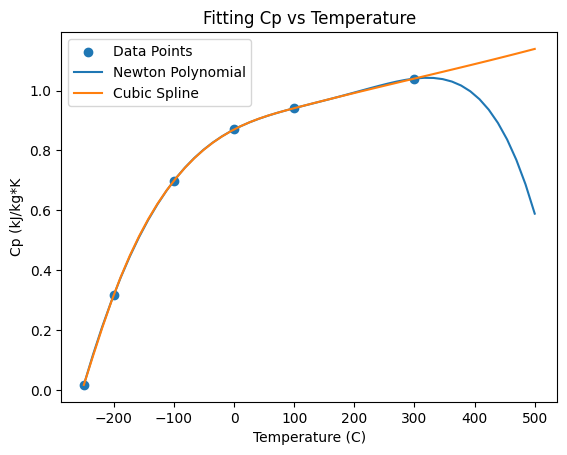

In [48]:
import numpy as np
import matplotlib.pyplot as plt
## module LUdecomp3
''' c,d,e = LUdecomp3(c,d,e).
    LU decomposition of tridiagonal matrix [a], where {c}, {d}
    and {e} are the diagonals of [a]. On output
    {c},{d} and {e} are the diagonals of the decomposed matrix.

    x = LUsolve3(c,d,e,b).
    Solution of [a]{x} {b}, where {c}, {d} and {e} are the
    vectors returned from LUdecomp3.
'''

def LUdecomp3(c,d,e):
    n = len(d)
    for k in range(1,n):
        lam = c[k-1]/d[k-1]
        d[k] = d[k] - lam*e[k-1]
        c[k-1] = lam
    return c,d,e

def LUsolve3(c,d,e,b):
    n = len(d)
    for k in range(1,n):
        b[k] = b[k] - c[k-1]*b[k-1]
    b[n-1] = b[n-1]/d[n-1]
    for k in range(n-2,-1,-1):
        b[k] = (b[k] - e[k]*b[k+1])/d[k]
    return b

## module cubicSpline
''' k = curvatures(xData,yData).
    Returns the curvatures of cubic spline at its knots.

    y = evalSpline(xData,yData,k,x).
    Evaluates cubic spline at x. The curvatures k can be
    computed with the function 'curvatures'.
'''
import numpy as np

def curvatures(xData,yData):
    n = len(xData) - 1
    c = np.zeros(n)
    d = np.ones(n+1)
    e = np.zeros(n)
    k = np.zeros(n+1)
    c[0:n-1] = xData[0:n-1] - xData[1:n]
    d[1:n] = 2.0*(xData[0:n-1] - xData[2:n+1])
    e[1:n] = xData[1:n] - xData[2:n+1]
    k[1:n] =6.0*(yData[0:n-1] - yData[1:n]) \
                 /(xData[0:n-1] - xData[1:n]) \
             -6.0*(yData[1:n] - yData[2:n+1])   \
                 /(xData[1:n] - xData[2:n+1])
    LUdecomp3(c,d,e)
    LUsolve3(c,d,e,k)
    return k

def evalSpline(xData,yData,k,x):

    def findSegment(xData,x):
        iLeft = 0
        iRight = len(xData)- 1
        while 1:
            if (iRight-iLeft) <= 1: return iLeft
            i =(iLeft + iRight)//2
            if x < xData[i]: iRight = i
            else: iLeft = i

    i = findSegment(xData,x)
    h = xData[i] - xData[i+1]
    y = ((x - xData[i+1])**3/h - (x - xData[i+1])*h)*k[i]/6.0 \
      - ((x - xData[i])**3/h - (x - xData[i])*h)*k[i+1]/6.0   \
      + (yData[i]*(x - xData[i+1])                            \
       - yData[i+1]*(x - xData[i]))/h
    return y#

## module newtonPoly
import numpy as np
''' p = evalPoly(a,xData,x).
    Evaluates Newton's polynomial p at x. The coefficient
    vector 'a' can be computed by the function 'coeffts'.

    a = coeffts(xData,yData).
    Computes the coefficients of Newton's polynomial.
'''
def evalPoly(a,xData,x):
    n = len(xData) - 1  # Degree of polynomial
    p = a[n]
    for k in range(1,n+1):
        p = a[n-k] + (x -xData[n-k])*p
    return p

def coeffts(xData,yData):
    m = len(xData)  # Number of data points
    a = yData.copy()
    for k in range(1,m):
        a[k:m] = (a[k:m] - a[k-1])/(xData[k:m] - xData[k-1])
    return a

xData = np.array([-250,-200,-100,0,100,300])
yData = np.array([0.0163,0.318,0.699,0.870,0.941,1.04])

x=np.linspace(-250,500,50)

#Plot Polynomial
a = coeffts(xData,yData)
y_poly = []
for i in x:
    y_poly.append(evalPoly(a,xData,i))

k = curvatures(xData,yData)
y_spline = []
for i in x:
    y_spline.append(evalSpline(xData,yData,k,i))

# ---- Plot everything ----
plt.figure()

plt.scatter(xData, yData, label="Data Points")
plt.plot(x, y_poly, label="Newton Polynomial")
plt.plot(x, y_spline, label="Cubic Spline")

plt.legend()
plt.xlabel("Temperature (C)")
plt.ylabel("Cp (kJ/kg*K")
plt.title("Fitting Cp vs Temperature")

plt.show()

